# TP3 - KPIs et attribution multicanal de Lumina & Co

## 1. Définir l'objectif du notebook

**Question CMO :** quels canaux fonctionnent réellement et comment l'attribution change-t-elle l'arbitrage budgétaire ?

Ce notebook doit produire :

- les KPI par canal et par campagne : taux de conversion, CPA, CAC et ROAS ;
- une comparaison des classements obtenus selon chaque KPI ;
- une attribution du chiffre d'affaires en **first touch** et **last touch** ;
- une recommandation budgétaire argumentée, avec ses limites.

Définitions utilisées :

- **Taux de conversion** = conversions / clients uniques exposés ;
- **CPA** = coût / conversions ;
- **CAC** = coût / nouveaux clients acquis ;
- **ROAS** = chiffre d'affaires attribué / coût.

Les KPI directs par canal attribuent la conversion et son chiffre d'affaires au dernier contact avant achat. La comparaison first/last touch montre ensuite la sensibilité de cette lecture au modèle choisi.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid")

DATA_DIR = Path("Lumina & Co - CRM")
CAMPAIGNS_PATH = DATA_DIR / "campaigns.csv"
CUSTOMERS_PATH = DATA_DIR / "customers.csv"
TOUCHPOINTS_PATH = DATA_DIR / "touchpoints.csv"
TRANSACTIONS_PATH = DATA_DIR / "transactions.csv"

required_paths = [CAMPAIGNS_PATH, CUSTOMERS_PATH, TOUCHPOINTS_PATH, TRANSACTIONS_PATH]
missing_paths = [str(path) for path in required_paths if not path.exists()]
assert not missing_paths, f"Fichiers introuvables : {missing_paths}"

campaigns = pd.read_csv(CAMPAIGNS_PATH, parse_dates=["start_date", "end_date"])
customers = pd.read_csv(CUSTOMERS_PATH, parse_dates=["first_purchase", "last_purchase"])
touchpoints = pd.read_csv(TOUCHPOINTS_PATH, parse_dates=["timestamp"])
transactions = pd.read_csv(TRANSACTIONS_PATH, parse_dates=["invoice_date"])

print(f"Campagnes : {len(campaigns):,}")
print(f"Clients : {len(customers):,}")
print(f"Touchpoints : {len(touchpoints):,}")
print(f"Lignes de transaction : {len(transactions):,}")
print("\nCanaux :", sorted(touchpoints["channel"].dropna().unique()))
print("Colonnes touchpoints :", touchpoints.columns.tolist())

Campagnes : 6
Clients : 50,295
Touchpoints : 1,080,897
Lignes de transaction : 1,613,433

Canaux : ['affiliate', 'direct', 'display', 'email', 'retargeting', 'search_paid', 'social']
Colonnes touchpoints : ['touchpoint_id', 'customer_id', 'invoice_id', 'journey_id', 'campaign_name', 'timestamp', 'channel', 'position', 'n_touchpoints', 'click', 'converted', 'cost', 'is_last_before_conversion']


## 2. Implémenter le traitement principal

### 2.1 Contrôler les données et reconstruire la valeur des conversions

Une ligne `converted = 1` représente le dernier contact avant une conversion et porte son `invoice_id`. La facture est valorisée à partir des lignes de `transactions.csv` :

$$CA_{facture} = \sum (quantité \times prix\ unitaire)$$

Les contrôles ci-dessous vérifient l'unicité des clés, la présence des factures converties dans les transactions et la cohérence du marqueur de dernier contact.

In [2]:
def normalize_identifier(series: pd.Series) -> pd.Series:
    """Normalise les identifiants lus comme nombres ou chaînes sans altérer les valeurs manquantes."""
    return series.astype("string").str.strip().str.replace(r"\.0$", "", regex=True)


touchpoints["invoice_key"] = normalize_identifier(touchpoints["invoice_id"])
transactions["invoice_key"] = normalize_identifier(transactions["invoice_id"])
touchpoints["customer_key"] = normalize_identifier(touchpoints["customer_id"])
transactions["customer_key"] = normalize_identifier(transactions["customer_id"])
customers["customer_key"] = normalize_identifier(customers["customer_id"])

transactions["line_revenue"] = transactions["quantity"] * transactions["unit_price"]
invoice_values = (
    transactions.groupby("invoice_key", as_index=False)
    .agg(
        invoice_revenue=("line_revenue", "sum"),
        invoice_date=("invoice_date", "min"),
        invoice_customer=("customer_key", "first"),
    )
)

converted_touchpoints = touchpoints.loc[touchpoints["converted"].eq(1)].copy()
converted_touchpoints = converted_touchpoints.merge(
    invoice_values,
    on="invoice_key",
    how="left",
    validate="many_to_one",
)
converted_touchpoints = converted_touchpoints.merge(
    customers[["customer_key", "first_purchase"]],
    on="customer_key",
    how="left",
    validate="many_to_one",
)
converted_touchpoints["is_new_customer"] = (
    converted_touchpoints["invoice_date"].dt.normalize()
    == converted_touchpoints["first_purchase"].dt.normalize()
)

quality_checks = pd.Series(
    {
        "touchpoint_id dupliqués": touchpoints["touchpoint_id"].duplicated().sum(),
        "conversions": len(converted_touchpoints),
        "conversions sans invoice_id": converted_touchpoints["invoice_key"].isna().sum(),
        "factures converties non retrouvées": converted_touchpoints["invoice_revenue"].isna().sum(),
        "conversions non marquées dernier contact": converted_touchpoints["is_last_before_conversion"].ne(1).sum(),
        "journeys convertis dupliqués": converted_touchpoints["journey_id"].duplicated().sum(),
        "clients convertis sans first_purchase": converted_touchpoints["first_purchase"].isna().sum(),
    },
    name="valeur",
)

display(quality_checks.to_frame())
print("\nTypes des clés avant normalisation :")
print("touchpoints.invoice_id :", touchpoints["invoice_id"].dtype)
print("transactions.invoice_id :", transactions["invoice_id"].dtype)
print(f"\nCA des factures converties retrouvé : {converted_touchpoints['invoice_revenue'].sum():,.2f} €")

,valeur
touchpoint_id dupliqués,0
conversions,94366
conversions sans invoice_id,0
factures converties non retrouvées,0
conversions non marquées dernier contact,0
journeys convertis dupliqués,0
clients convertis sans first_purchase,0



Types des clés avant normalisation :
touchpoints.invoice_id : float64
transactions.invoice_id : str

CA des factures converties retrouvé : 18,401,677.83 €


In [3]:
campaign_reconciliation = pd.DataFrame(
    {
        "source": ["campaigns.csv", "touchpoints + transactions"],
        "coût": [campaigns["total_cost"].sum(), touchpoints["cost"].sum()],
        "conversions": [campaigns["n_conversions"].sum(), len(converted_touchpoints)],
        "CA": [campaigns["revenue"].sum(), converted_touchpoints["invoice_revenue"].sum()],
    }
)
campaign_reconciliation["ROAS"] = campaign_reconciliation["CA"] / campaign_reconciliation["coût"]
display(campaign_reconciliation)

exact_new_customers = converted_touchpoints["invoice_date"].eq(converted_touchpoints["first_purchase"]).sum()
day_new_customers = converted_touchpoints["is_new_customer"].sum()
print(f"Primo-achats, égalité exacte : {exact_new_customers:,}")
print(f"Primo-achats, même date civile : {day_new_customers:,}")

channel_costs = touchpoints.groupby("channel")["cost"].sum().sort_values(ascending=False)
display(channel_costs.rename("coût").to_frame())

,source,coût,conversions,CA,ROAS
0,campaigns.csv,"1,348,008.27",94366,"5,560,094.67",4.12
1,touchpoints + transactions,"1,348,008.27",94366,"18,401,677.83",13.65


Primo-achats, égalité exacte : 1,700
Primo-achats, même date civile : 1,749


,coût
channel,
affiliate,"1,128,776.74"
social,"166,324.04"
search_paid,"47,264.48"
email,"2,263.28"
retargeting,"1,897.65"
display,"1,482.10"
direct,0.00


### 2.2 Calculer les KPI par canal

Pour rester cohérent entre les canaux :

- le coût vient de tous les touchpoints du canal ;
- les conversions et le CA direct vont au dernier contact avant achat ;
- le CAC utilise l'égalité exacte demandée entre `invoice_date` et `first_purchase` ;
- le taux de conversion utilise les clients uniques touchés comme dénominateur.

Le canal `direct` est conservé pour décrire les parcours mais exclu des classements de coût : aucun coût média ne lui est affecté, donc son CPA, son CAC et son ROAS ne sont pas comparables.

In [4]:
def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    """Divise deux séries et retourne NaN lorsque le dénominateur est nul."""
    return numerator.div(denominator.replace(0, np.nan))


def compute_channel_kpis(
    touchpoint_data: pd.DataFrame,
    conversion_data: pd.DataFrame,
) -> pd.DataFrame:
    """Calcule les KPI directs par canal sur une base homogène."""
    prepared_touchpoints = touchpoint_data.assign(
        customer_campaign_key=(
            touchpoint_data["campaign_name"].astype("string")
            + "|"
            + touchpoint_data["customer_key"]
        )
    )
    exposure = prepared_touchpoints.groupby("channel").agg(
        touchpoints=("touchpoint_id", "size"),
        clients_exposés=("customer_key", "nunique"),
        expositions_client_campagne=("customer_campaign_key", "nunique"),
        clics=("click", "sum"),
        coût=("cost", "sum"),
    )
    outcomes = conversion_data.groupby("channel").agg(
        conversions=("journey_id", "nunique"),
        nouveaux_clients=("is_new_customer", "sum"),
        CA_direct=("invoice_revenue", "sum"),
    )
    result = exposure.join(outcomes, how="left").fillna(0)
    result["CTR"] = safe_divide(result["clics"], result["touchpoints"])
    result["taux_conversion"] = safe_divide(
        result["conversions"], result["expositions_client_campagne"]
    )
    result["CPA"] = safe_divide(result["coût"], result["conversions"])
    result["CAC"] = safe_divide(result["coût"], result["nouveaux_clients"])
    result["ROAS_direct"] = safe_divide(result["CA_direct"], result["coût"])
    return result.sort_values("ROAS_direct", ascending=False)


channel_kpis = compute_channel_kpis(touchpoints, converted_touchpoints)
paid_channel_kpis = channel_kpis.loc[channel_kpis["coût"].gt(0)].copy()

display(
    channel_kpis.style.format(
        {
            "touchpoints": "{:,.0f}",
            "clients_exposés": "{:,.0f}",
            "expositions_client_campagne": "{:,.0f}",
            "clics": "{:,.0f}",
            "coût": "{:,.0f} €",
            "conversions": "{:,.0f}",
            "nouveaux_clients": "{:,.0f}",
            "CA_direct": "{:,.0f} €",
            "CTR": "{:.1%}",
            "taux_conversion": "{:.1%}",
            "CPA": "{:.2f} €",
            "CAC": "{:.2f} €",
            "ROAS_direct": "{:.2f}",
        },
        na_rep="non comparable",
    )
)

rankings = pd.DataFrame(
    {
        "CPA (croissant)": paid_channel_kpis["CPA"].sort_values(na_position="last").index,
        "CAC (croissant)": paid_channel_kpis["CAC"].sort_values(na_position="last").index,
        "ROAS (décroissant)": paid_channel_kpis["ROAS_direct"].sort_values(ascending=False).index,
        "Conversion (décroissant)": paid_channel_kpis["taux_conversion"].sort_values(ascending=False).index,
    },
    index=range(1, len(paid_channel_kpis) + 1),
)
rankings.index.name = "rang"
display(rankings)

,touchpoints,clients_exposés,expositions_client_campagne,clics,coût,conversions,nouveaux_clients,CA_direct,CTR,taux_conversion,CPA,CAC,ROAS_direct
channel,,,,,,,,,,,,,
retargeting,"158,102","43,482","96,157","83,548","1,898 €","22,563",441,"4,455,953 €",52.8%,23.5%,0.08 €,4.30 €,2348.15
email,"150,733","43,141","93,379","75,666","2,263 €","14,355",258,"2,603,351 €",50.2%,15.4%,0.16 €,8.77 €,1150.26
search_paid,"41,334","17,513","28,062","31,548","47,264 €","13,666",266,"2,824,693 €",76.3%,48.7%,3.46 €,177.69 €,59.76
affiliate,"54,516","20,800","35,063","44,884","1,128,777 €","26,979",507,"5,313,106 €",82.3%,76.9%,41.84 €,2226.38 €,4.71
display,"316,530","47,555","131,362","142,192","1,482 €",0,0,0 €,44.9%,0.0%,non comparable,non comparable,0.00
social,"315,763","47,500","131,173","142,089","166,324 €",0,0,0 €,45.0%,0.0%,non comparable,non comparable,0.00
direct,"43,919","18,232","29,646","34,441",0 €,"16,803",277,"3,204,575 €",78.4%,56.7%,0.00 €,0.00 €,non comparable


,CPA (croissant),CAC (croissant),ROAS (décroissant),Conversion (décroissant)
rang,,,,
1,retargeting,retargeting,retargeting,affiliate
2,email,email,email,search_paid
3,search_paid,search_paid,search_paid,retargeting
4,affiliate,affiliate,affiliate,email
5,display,display,display,display
6,social,social,social,social


### 2.3 Comparer les campagnes et le `primary_channel`

Les agrégats de `campaigns.csv` sont conservés comme référentiel officiel au niveau campagne. Le CAC est ajouté à partir des primo-achats reconstruits. Le champ `primary_channel` décrit le canal dominant de la campagne ; il ne prouve pas qu'il est le plus performant.

In [5]:
new_customers_by_campaign = (
    converted_touchpoints.groupby("campaign_name")["is_new_customer"].sum().rename("new_customers")
)
campaign_kpis = campaigns.set_index("campaign_name").join(new_customers_by_campaign)
campaign_kpis["cac"] = safe_divide(campaign_kpis["total_cost"], campaign_kpis["new_customers"])
campaign_kpis["calculated_cpa"] = safe_divide(
    campaign_kpis["total_cost"], campaign_kpis["n_conversions"]
)
campaign_kpis["calculated_roas"] = safe_divide(
    campaign_kpis["revenue"], campaign_kpis["total_cost"]
)

campaign_view = campaign_kpis[
    [
        "primary_channel",
        "n_clients",
        "n_conversions",
        "new_customers",
        "conversion_rate",
        "calculated_cpa",
        "cac",
        "calculated_roas",
    ]
].sort_values("calculated_roas", ascending=False)

display(
    campaign_view.style.format(
        {
            "n_clients": "{:,.0f}",
            "n_conversions": "{:,.0f}",
            "new_customers": "{:,.0f}",
            "conversion_rate": "{:.1%}",
            "calculated_cpa": "{:.2f} €",
            "cac": "{:.2f} €",
            "calculated_roas": "{:.2f}",
        }
    )
)

,primary_channel,n_clients,n_conversions,new_customers,conversion_rate,calculated_cpa,cac,calculated_roas
campaign_name,,,,,,,,
Winter_Promo,display,"25,638","14,170",200,55.3%,9.45 €,669.75 €,5.35
Black_Friday,display,"26,937","18,777",261,69.7%,10.96 €,788.31 €,4.65
Back_to_School,social,"25,527","13,192",263,51.7%,12.07 €,605.54 €,4.56
Spring_Launch,display,"26,612","20,372",654,76.5%,18.40 €,573.11 €,4.50
Valentine,display,"25,850","15,141",259,58.6%,16.34 €,955.47 €,3.45
Summer_Sale,display,"25,378","12,714",112,50.1%,17.84 €,2024.77 €,2.74


### 2.4 Comparer first touch et last touch

- **First touch** : 100 % du crédit va au premier contact observé du parcours converti.
- **Last touch** : 100 % du crédit va au dernier contact avant l'achat.

Ces modèles sont volontairement simples. Leur écart révèle le rôle des canaux de découverte et de fermeture, mais ne mesure pas la causalité.

In [6]:
def build_attribution_tables(touchpoint_data, conversion_data):
    converted_journeys = conversion_data[["journey_id", "invoice_revenue"]].drop_duplicates("journey_id")
    journey_touchpoints = touchpoint_data.merge(
        converted_journeys[["journey_id"]],
        on="journey_id",
        how="inner",
        validate="many_to_one",
    )
    ordered = journey_touchpoints.sort_values(
        ["journey_id", "position", "timestamp", "touchpoint_id"]
    )
    first_touch = ordered.drop_duplicates("journey_id", keep="first")[["journey_id", "channel"]]
    first_touch = first_touch.rename(columns={"channel": "first_touch"})
    last_touch = conversion_data[["journey_id", "channel"]].rename(columns={"channel": "last_touch"})
    journeys = converted_journeys.merge(first_touch, on="journey_id", validate="one_to_one")
    journeys = journeys.merge(last_touch, on="journey_id", validate="one_to_one")

    first = journeys.groupby("first_touch").agg(
        conversions_first=("journey_id", "nunique"),
        CA_first=("invoice_revenue", "sum"),
    )
    last = journeys.groupby("last_touch").agg(
        conversions_last=("journey_id", "nunique"),
        CA_last=("invoice_revenue", "sum"),
    )
    comparison = first.join(last, how="outer").fillna(0)
    comparison["part_CA_first"] = comparison["CA_first"] / comparison["CA_first"].sum()
    comparison["part_CA_last"] = comparison["CA_last"] / comparison["CA_last"].sum()
    comparison["écart_points"] = 100 * (comparison["part_CA_first"] - comparison["part_CA_last"])
    return journeys, comparison.sort_values("part_CA_first", ascending=False)


journey_attribution, attribution_comparison = build_attribution_tables(
    touchpoints, converted_touchpoints
)
journey_lengths = touchpoints.groupby("journey_id")["touchpoint_id"].size()
print(f"Touchpoints moyens par parcours : {journey_lengths.mean():.2f}")
print(f"Touchpoints médians par parcours : {journey_lengths.median():.0f}")
print(f"Part des parcours avec plusieurs contacts : {journey_lengths.gt(1).mean():.1%}")
display(
    attribution_comparison.style.format(
        {
            "conversions_first": "{:,.0f}",
            "CA_first": "{:,.0f} €",
            "conversions_last": "{:,.0f}",
            "CA_last": "{:,.0f} €",
            "part_CA_first": "{:.1%}",
            "part_CA_last": "{:.1%}",
            "écart_points": "{:+.1f} pts",
        }
    )
)

Touchpoints moyens par parcours : 5.03
Touchpoints médians par parcours : 5
Part des parcours avec plusieurs contacts : 99.0%


,conversions_first,CA_first,conversions_last,CA_last,part_CA_first,part_CA_last,écart_points
first_touch,,,,,,,
display,"38,733","7,555,024 €",0,0 €,41.1%,0.0%,+41.1 pts
social,"38,373","7,517,681 €",0,0 €,40.9%,0.0%,+40.9 pts
retargeting,"3,558","701,423 €","22,563","4,455,953 €",3.8%,24.2%,-20.4 pts
search_paid,"3,408","675,676 €","13,666","2,824,693 €",3.7%,15.4%,-11.7 pts
affiliate,"3,665","673,219 €","26,979","5,313,106 €",3.7%,28.9%,-25.2 pts
email,"3,358","665,557 €","14,355","2,603,351 €",3.6%,14.1%,-10.5 pts
direct,"3,271","613,097 €","16,803","3,204,575 €",3.3%,17.4%,-14.1 pts


## 3. Exécuter et afficher les résultats

### 3.1 Visualiser le basculement du crédit

La dépense observée est comparée à la part de CA attribuée par chaque modèle. Cette comparaison ne constitue pas une allocation optimale : elle montre à quel point la décision changerait si le CMO ne regardait qu'un seul modèle.

,part_CA_first,part_CA_last,part_coût_observé
first_touch,,,
display,41.1%,0.0%,0.1%
social,40.9%,0.0%,12.3%
retargeting,3.8%,24.2%,0.1%
search_paid,3.7%,15.4%,3.5%
affiliate,3.7%,28.9%,83.7%
email,3.6%,14.1%,0.2%
direct,3.3%,17.4%,0.0%


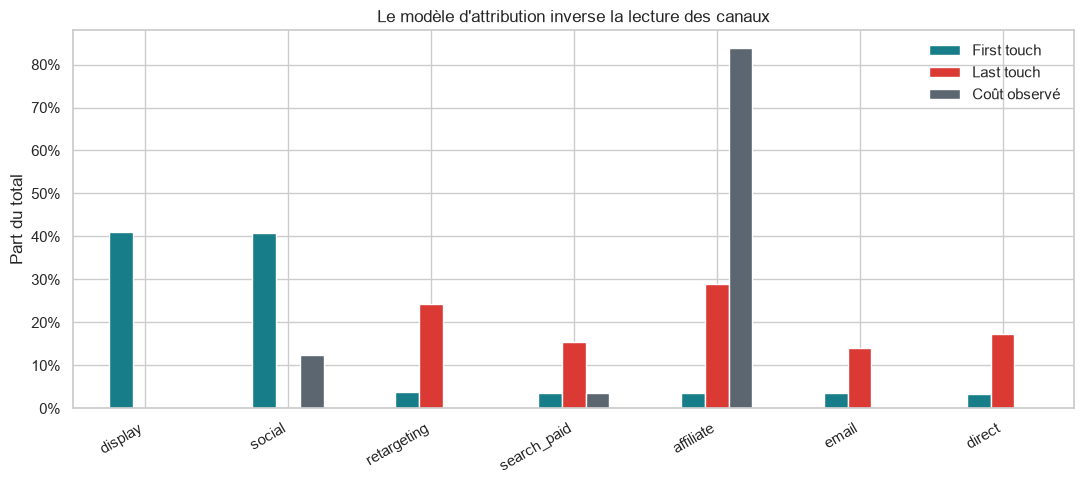

In [7]:
budget_comparison = attribution_comparison[["part_CA_first", "part_CA_last"]].copy()
budget_comparison["part_coût_observé"] = (
    channel_kpis["coût"] / channel_kpis["coût"].sum()
)
budget_comparison = budget_comparison.fillna(0).sort_values("part_CA_first", ascending=False)

display(
    budget_comparison.style.format(
        {
            "part_CA_first": "{:.1%}",
            "part_CA_last": "{:.1%}",
            "part_coût_observé": "{:.1%}",
        }
    )
)

plot_data = budget_comparison.rename(
    columns={
        "part_CA_first": "First touch",
        "part_CA_last": "Last touch",
        "part_coût_observé": "Coût observé",
    }
)
ax = plot_data.plot(kind="bar", figsize=(11, 5), color=["#177E89", "#DB3A34", "#5C6670"])
ax.set_title("Le modèle d'attribution inverse la lecture des canaux")
ax.set_xlabel("")
ax.set_ylabel("Part du total")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.xticks(rotation=30, ha="right")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("attribution_multicanal.png", dpi=180, bbox_inches="tight")
plt.show()

In [8]:
converted_journey_values = journey_attribution[["journey_id", "invoice_revenue"]]
linear_touchpoints = touchpoints.merge(
    converted_journey_values,
    on="journey_id",
    how="inner",
    validate="many_to_one",
)
observed_journey_sizes = linear_touchpoints.groupby("journey_id")["touchpoint_id"].transform("size")
linear_touchpoints["linear_credit"] = (
    linear_touchpoints["invoice_revenue"] / observed_journey_sizes
)
linear_attribution = (
    linear_touchpoints.groupby("channel")["linear_credit"]
    .sum()
    .rename("CA_multi_touch_linéaire")
    .to_frame()
)
linear_attribution["part_CA_multi_touch"] = (
    linear_attribution["CA_multi_touch_linéaire"]
    / linear_attribution["CA_multi_touch_linéaire"].sum()
)

model_comparison = attribution_comparison.join(linear_attribution, how="outer").fillna(0)
display(
    model_comparison[
        ["part_CA_first", "part_CA_multi_touch", "part_CA_last"]
    ].sort_values("part_CA_multi_touch", ascending=False).style.format("{:.1%}")
)

,part_CA_first,part_CA_multi_touch,part_CA_last
first_touch,,,
display,41.1%,17.3%,0.0%
social,40.9%,17.1%,0.0%
affiliate,3.7%,15.7%,28.9%
retargeting,3.8%,14.6%,24.2%
direct,3.3%,12.2%,17.4%
search_paid,3.7%,11.8%,15.4%
email,3.6%,11.5%,14.1%


### 3.2 Lecture business et recommandation

#### Ce que montrent les données

1. Les parcours sont réellement multicanaux : **5,03 contacts en moyenne** et **99,0 %** des parcours convertis comportent plusieurs contacts.
2. Le last touch donne 100 % du crédit aux canaux de fermeture. L'affiliation reçoit **28,9 %** du CA last touch, le retargeting **24,2 %**, le direct **17,4 %**, le search payant **15,4 %** et l'email **14,1 %**.
3. Le first touch inverse la lecture : display reçoit **41,1 %** du CA attribué et social **40,9 %**, alors qu'ils ne ferment aucune vente dans ces parcours.
4. Une attribution linéaire réduit ces extrêmes : display **17,3 %**, social **17,1 %**, affiliation **15,7 %**, retargeting **14,6 %**, direct **12,2 %**, search payant **11,8 %** et email **11,5 %**.
5. L'affiliation absorbe **83,7 % du coût observé**, contre 28,9 % du CA en last touch et 15,7 % en linéaire. Ce décalage justifie un audit du coût et un test d'incrémentalité avant de maintenir ce poids budgétaire.

#### Ce que cela signifie

Une lecture uniquement last touch sous-évaluerait fortement display et social, qui ouvrent les parcours. À l'inverse, une lecture uniquement first touch sous-évaluerait les canaux qui ferment les ventes. Le `primary_channel` d'une campagne décrit son orientation, pas sa performance propre : cinq campagnes sur six sont étiquetées display alors que ce canal n'apparaît jamais en dernier contact.

Les volumes de touchpoints et de clics sont des **métriques de vanité** lorsqu'ils sont lus seuls. Ils deviennent utiles lorsqu'ils sont reliés à un objectif et à un coût : CTR, taux de conversion, CPA, CAC ou revenu incrémental.

#### Recommandation au CMO

- Ne pas piloter le budget avec le seul last touch.
- Utiliser une lecture multi-touch linéaire comme tableau de bord provisoire, accompagnée des vues first et last touch pour comprendre le rôle de chaque canal.
- Ne pas transférer mécaniquement le budget selon les parts attribuées : l'attribution décrit les parcours, elle ne démontre pas l'incrémentalité.
- Auditer en priorité l'affiliation, qui concentre 83,7 % du coût observé.
- Protéger un budget test pour display et social, puis mesurer leur apport par des tests géographiques, temporels ou de holdout.
- Évaluer email et retargeting par groupes témoins, car leurs coûts enregistrés très faibles produisent des ROAS directs anormalement élevés.

#### Limites et confiance

- Le CA de `campaigns.csv` est de **5,56 M€**, contre **18,40 M€** pour les factures converties reconstruites depuis `transactions.csv`. Les coûts et conversions concordent, mais la définition du revenu doit être réconciliée avant une décision financière définitive.
- First touch, last touch et linéaire sont des règles de partage du crédit, pas des estimations causales.
- Le canal direct n'a aucun coût enregistré et ne peut pas être comparé par CPA, CAC ou ROAS.
- Le taux de conversion par canal repose sur les expositions client-campagne ; il ne doit pas être comparé directement au taux agrégé d'une campagne sans rappeler ce dénominateur.

## 4. Ajouter des tests automatisés

Ces assertions vérifient les invariants qui rendraient les résultats faux s'ils étaient violés : couverture des conversions, conservation du CA entre modèles, bornes des taux et cohérence des KPI publiés.

In [9]:
assert touchpoints["touchpoint_id"].is_unique
assert converted_touchpoints["journey_id"].is_unique
assert converted_touchpoints["invoice_revenue"].notna().all()
assert converted_touchpoints["first_purchase"].notna().all()
assert channel_kpis["taux_conversion"].between(0, 1).all()
assert np.allclose(campaign_kpis["calculated_cpa"], campaign_kpis["cpa"], rtol=1e-3)
assert np.allclose(campaign_kpis["calculated_roas"], campaign_kpis["roas"], rtol=2e-3)
assert np.isclose(
    attribution_comparison["CA_first"].sum(),
    attribution_comparison["CA_last"].sum(),
)
assert np.isclose(
    linear_attribution["CA_multi_touch_linéaire"].sum(),
    converted_touchpoints["invoice_revenue"].sum(),
)
assert np.isclose(touchpoints["cost"].sum(), campaigns["total_cost"].sum())
assert (
    paid_channel_kpis.loc[paid_channel_kpis["CAC"].notna(), "CAC"]
    >= paid_channel_kpis.loc[paid_channel_kpis["CAC"].notna(), "CPA"]
).all()

print("Tous les tests sont passés.")

Tous les tests sont passés.
